In [5]:
# Argparse
import argparse

parser = argparse.ArgumentParser()
parser.add_argument("--fold", type=int, default=0)
args = parser.parse_args()

fold_id = args.fold
print(f"Using fold_id: {fold_id}")

usage: ipykernel_launcher.py [-h] [--fold FOLD]
ipykernel_launcher.py: error: argument --fold: invalid int value: '/run/user/1012/jupyter/runtime/kernel-v3274e8c14ebf57f5e8810bdfa97ba945b7831ad51.json'


SystemExit: 2

/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# Hyperparameters

In [10]:
USE_WANDB = True
n_folds = 5

N_SAMPLES = 5000
# N_SAMPLES = None
random_state = 11
fold_id = 0

FILTERS = {
    "duration_unit": ["h"],
    "effect": ["MOR", "POP", "GRO", "BEH", "REP", "ITX", "PHY", "DVP", "MPH"],
}

SPLIT_SALTS = False
REMOVE_LONE = False
REMOVE_METALS = False

MAX_CONC_VALUE = 10000
DURATION_FILL_VALUE = 1e-6
MAX_DURATION_HOURS = 9000.0

# Setup

In [11]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    possible = Path.cwd() / "vollmers/gnn-thesis/gnn-thesis"
    if (possible / "src").exists():
        PROJECT_ROOT = possible

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    import wandb
except ImportError:
    wandb = None

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils.smiles import from_smiles

from src.data.io import load_data
from src.data.cleaning import process_data, print_mol_types
from src.data.graph_building import build_graphs
from src.data.metadata import sequential_encoder, build_config
from src.data.cleaning import fragment_count, is_salt, has_metal, is_single_node
from src.data.splitting import butina_split, show_split_info
from src.data.sampling import LoadData, show_loader_info, display_sampling_effect
from src.training.loops import train
from src.visualization.training_plots import  plot_training, plot_training_metrics, plot_group_training


pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

print("Imports imported")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports imported


# Load, filter and preprocess data


In [12]:
DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

print(f"Data path: {DATA_PATH}")

df_all = load_data(DATA_PATH)

df_processed = process_data(
    df_all,
    n_samples=N_SAMPLES,
    random_state=random_state,
    filters=FILTERS,
    require_duration=False,
    require_taxid=True,
    split_salts=SPLIT_SALTS,
    remove_lone=REMOVE_LONE,
    remove_metals=REMOVE_METALS,
    max_conc_value=MAX_CONC_VALUE,
    duration_fill_value=DURATION_FILL_VALUE,
    max_duration_hours=MAX_DURATION_HOURS,
    log_transform_duration=True,
    keep_duration_raw=True,
)

print()
print_mol_types(df_processed)

df_processed


Data path: /home/vollmers/gnn-thesis/Data/toxicity_all.csv
Filters
conc > 0 and <= 10000
True: 0.990
duration_unit: ['h']
True: 0.980
effect: ['MOR', 'POP', 'GRO', 'BEH', 'REP', 'ITX', 'PHY', 'DVP', 'MPH']
True: 0.981
require_taxid: True
True: 0.995
duration <= 9000.0 h or missing
True: 0.986

Loaded and masked training data
Rows in full data: 561,100
Rows after mask: 525,852
Rows before preprocessing: 525,852
Rows after preprocessing:  525,852
Rows removed: 0

Total molecules: 5000
Unique molecules: 2479
Disconnected species: 1213, 24.26%
Single-node species: 90, 1.80%
Metals: 982, 19.64%


,SK_unique_id,species_common_name,species_latin_name,CAS,chemical_name,conc_unit,conc,duration,duration_unit,effect,endpoint,SMILES,organism_lifestage,administration_route,species_sci_name,taxid,superkingdom,kingdom,phylum,subphylum,class,order,family,genus,species,species_group,log10c,duration_raw
0,AQTER1194716,Two-Spotted Spider Mite,tetranychus urticae,2312-35-8,"2-[4-(1,1-Dimethylethyl)phenoxy]cyclohexyl 2-propynyl ester sulfurous acid",mg/L,1437.912,1.681241,h,MOR,EC50,C#CCOS(=O)OC1CCCCC1Oc1ccc(C(C)(C)C)cc1,adult,soaking,tetranychus urticae,32264,2759.0,33208.0,6656.0,6843.0,6854.0,83136.0,32262.0,32263.0,32264.0,insects,3.157732,48.0
1,AQTER700564,Ciliate,tetrahymena pyriformis,1423-60-5,3-Butyn-2-one,mg/L,0.176,1.662758,h,POP,EC50,C#CC(C)=O,adult,static,tetrahymena pyriformis,5908,2759.0,NaN,5878.0,431838.0,6020.0,31277.0,291294.0,5890.0,5908.0,protozoans,-0.754487,46.0
2,AQTER1155713,Wild Portulaca,portulaca oleracea,8069-49-6,"1,3-Dichloro-1-propene mixt. with trichloronitromethane",kg/m2,0.025,3.772908,h,POP,LOEC,ClC=CCCl.O=[N+]([O-])C(Cl)(Cl)Cl,adult,environmental,portulaca oleracea,46147,2759.0,33090.0,35493.0,131221.0,3398.0,3524.0,3581.0,3582.0,46147.0,plants,-1.602060,5928.0
3,AQTER693103,San Paulo Shrimp,penaeus paulensis,7664-41-7,Ammonia,mg/L,21.980,1.982271,h,MOR,EC50,N,early,fill,penaeus paulensis,71413,2759.0,33208.0,6656.0,6657.0,6681.0,6683.0,6685.0,133894.0,71413.0,crustaceans,1.342028,96.0
4,AQTER579917,Midge,chironomus tentans,1420-04-8,"5-Chloro-N-(2-chloro-4-nitrophenyl)-2-hydrozybenzamide, compd. with 2-aminoe...",mg/L,0.228,1.982271,h,ITX,EC50,NCCO.O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,adult,static,chironomus tentans,7153,2759.0,33208.0,6656.0,6960.0,50557.0,7147.0,7149.0,7150.0,7153.0,insects,-0.642065,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,RTECS5308,mouse,Mus musculus,18109-50-7,"Acetanilide, 2',6'-dimethyl-N-(2-piperidinoethyl)-2-phenyl-",mg/kg,108.000,-6.000000,h,MOR,EC50,Cc1cccc(C)c1N(CCN1CCCCC1)C(=O)Cc1ccccc1,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,2.033424,NaN
4996,AQTER1392988,Midge,chironomus xanthus,2008-39-1,"2-(2,4-Dichlorophenoxy)acetic acid compd. with N-methylmethanamine (1:1)",mg/L,0.426,2.283301,h,GRO,NOEC,CNC.O=C(O)COc1ccc(Cl)cc1Cl,mid,renewal,chironomus xanthus,391769,2759.0,33208.0,6656.0,6960.0,50557.0,7147.0,7149.0,7150.0,391769.0,insects,-0.370590,192.0
4997,RTECS348165,rat,Rattus norvegicus,3542-36-7,"Stannane, dichlorodioctyl-",mg/kg,5500.000,-6.000000,h,MOR,EC50,CCCCCCCC[Sn](Cl)(Cl)CCCCCCCC,adult,fill,rattus norvegicus,10116,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10114.0,10116.0,rodents,3.740363,NaN
4998,AQTER624599,Red Sea Bream,chrysophrys major,7440-50-8,Copper,mg/L,0.110,1.857332,h,MOR,EC50,[Cu],early,fill,pagrus major,143350,2759.0,33208.0,7711.0,89593.0,186623.0,1489931.0,8169.0,8172.0,143350.0,fish,-0.958607,72.0


# Add Features - Encode Features - Create Graph Objects

## Node/Edge Features

In [13]:
from src.data.simple_featurizer import simple_featurizer
from src.data.features_graph import GraphFeaturizer

ATOM_FEATURES = (
    "atomic_num",
    "degree",
    "formal_charge",
    "num_hs",
    "hybridization",
    "is_aromatic",
    "is_in_ring",
    "atomic_mass",
    "period",
    "group",
    "covalent_radius",
    "vdw_radius",
    "is_metal",
)

BOND_FEATURES = (
    "bond_order",
    "is_conjugated",
    "is_in_ring",
    "stereo",
)

graph_featurizer = GraphFeaturizer(ATOM_FEATURES, BOND_FEATURES)

df_processed["features"] = df_processed["SMILES"].apply(graph_featurizer.featurize)

graph_cache = graph_featurizer.get_graph_cache()

sample_id = min(16, len(df_processed) - 1)

print()
print(f"{len(df_processed):,} rows with graph features created")
print(f"Total number of unique graphs: {len(graph_cache):,}")


5,000 rows with graph features created
Total number of unique graphs: 2,479


## Molecule Features

In [14]:
from src.data.features_mol import add_molecule_metadata

MOLECULE_CATEGORICAL_COLS = [
    "is_salt",
    "has_metal",
    "is_single_node",
]

MOLECULE_NUMERICAL_COLS = [
    "fragment_count",
    # "mol_weight",
    "log10_mol_weight",
    # "logp",
    # "tpsa",
    # "log10_tpsa_plus1",
    # "h_bond_donor_count",
    # "h_bond_acceptor_count",
    # "heavy_atom_count",
    # "log10_heavy_atom_count_plus1",
    # "hetero_atom_count",
    # "halogen_count",
    # "metal_count",
    # "transition_metal_count",
    # "ring_count",
    # "aromatic_ring_count",
    # "rotatable_bond_count",
    "formal_charge",
]

# Add molecule-level metadata for categorical and numerical encoders
df_processed = add_molecule_metadata(df_processed, categorical_cols=MOLECULE_CATEGORICAL_COLS, numerical_cols=MOLECULE_NUMERICAL_COLS)

## Encoding Features

In [15]:
USE_PRETRAINED_TAXID = True
PRETRAINED_TAXID_PATH = PROJECT_ROOT / "Data" / "moredata" / "pretrained_tax_emb.pkl.zip"
print(f"Pretrained taxid path: {PRETRAINED_TAXID_PATH}")

config_tax = {}

# Categorical encoding
exp_categorical_cols = [
    "species_group",
    "conc_unit",
    "endpoint", 
    "effect"
]

CATEGORICAL_COLS = exp_categorical_cols + MOLECULE_CATEGORICAL_COLS

df_categorical = df_processed[CATEGORICAL_COLS].copy()
df_categorical, categorical_encoder = sequential_encoder(df_categorical, CATEGORICAL_COLS)
# df_categorical now contains only the sequential data for selected columns

config_categorical = build_config(df_categorical, CATEGORICAL_COLS)

species_group_decoder = {encoded: original for original, encoded in categorical_encoder["species_group"].items()}

print("Categorical embedding config:")
print(config_categorical)

NUMERICAL_COLS = MOLECULE_NUMERICAL_COLS

Pretrained taxid path: /home/vollmers/gnn-thesis/Data/moredata/pretrained_tax_emb.pkl.zip
Categorical embedding config:
{'species_group': 19, 'conc_unit': 14, 'endpoint': 4, 'effect': 9, 'is_salt': 2, 'has_metal': 2, 'is_single_node': 2}


## Append Metadata to Graphs


In [16]:
graphs = build_graphs(
    df_processed,  
    df_categorical,
    CATEGORICAL_COLS,
    NUMERICAL_COLS,
    )

sample_graph = graphs[sample_id]

print(f"Graph objects created: {len(graphs):,}")
print()
print("Info for a sample graph:")
print(graphs[sample_id])


Graph objects created: 5,000

Info for a sample graph:
Data(x=[22, 187], edge_index=[2, 46], edge_attr=[46, 14], virtual_edge_index=[2, 0], virtual_edge_attr=[0, 10], fragment_id=[22], num_fragments=[1], smiles='C=C(C)CC(c1ccccc1OC)C1C(=O)NC(=O)NC1=O', y=2.1238515377044678, row_id=16, taxid_raw=10090, species_group=5, conc_unit=2, endpoint=0, effect=0, is_salt=0, has_metal=0, is_single_node=0, fragment_count=1.0, log10_mol_weight=2.480189085006714, formal_charge=0.0)


# Prepare for training

## Split data

Rows: 5,000
Unique groups: 2,357
Missing group values: 0
Fallback missing-cluster groups: 0
Train size: 4,000 (80.0%)
Val size:   1,000 (20.0%)

Unique molecules in train: 1,971
Unique molecules in val:   508
Val molecules not in train:  508

Target distribution
Train mean/std: 0.1393 / 2.4410
Val mean/std:   0.5321 / 2.0420


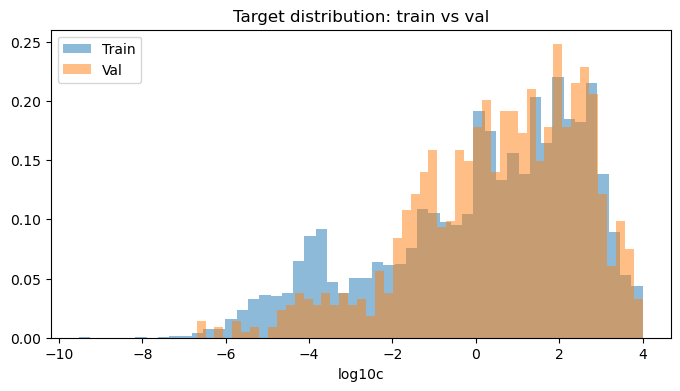

In [17]:
from sklearn.model_selection import GroupKFold
from src.data.splitting import load_butina_clusters, _build_dataset, butina_group_key

cluster_csv_path = PROJECT_ROOT / "Data" / "moredata" / "original" / "butina_cluster_lookup.csv"
cluster_col = "Cluster_at_cutoff_0.2"

folds = 5

smiles_to_cluster = load_butina_clusters(cluster_csv_path, cluster_col)

groups = pd.Series(
    [butina_group_key(graph.smiles, smiles_to_cluster) for graph in graphs],
    name="butina_group"
)

print(f"Rows: {len(groups):,}")
print(f"Unique groups: {groups.nunique():,}")
print(f"Missing group values: {groups.isna().sum():,}")
print(f"Fallback missing-cluster groups: {groups.str.startswith('__missing__::').sum():,}")

group_kfold = GroupKFold(n_splits=folds)

splits = list(group_kfold.split(graphs, groups=groups))

train_idx, val_idx = splits[fold_id]

train_dataset = _build_dataset(graphs, train_idx)
val_dataset = _build_dataset(graphs, val_idx)
test_dataset = None

show_split_info(train_dataset, val_dataset)

## Build DataLoaders


Train: 4000 dataset samples, 4000 sampled samples, 16 batches (batch_size=256)
Val: 1000 dataset samples, 1000 sampled samples, 4 batches (batch_size=256)


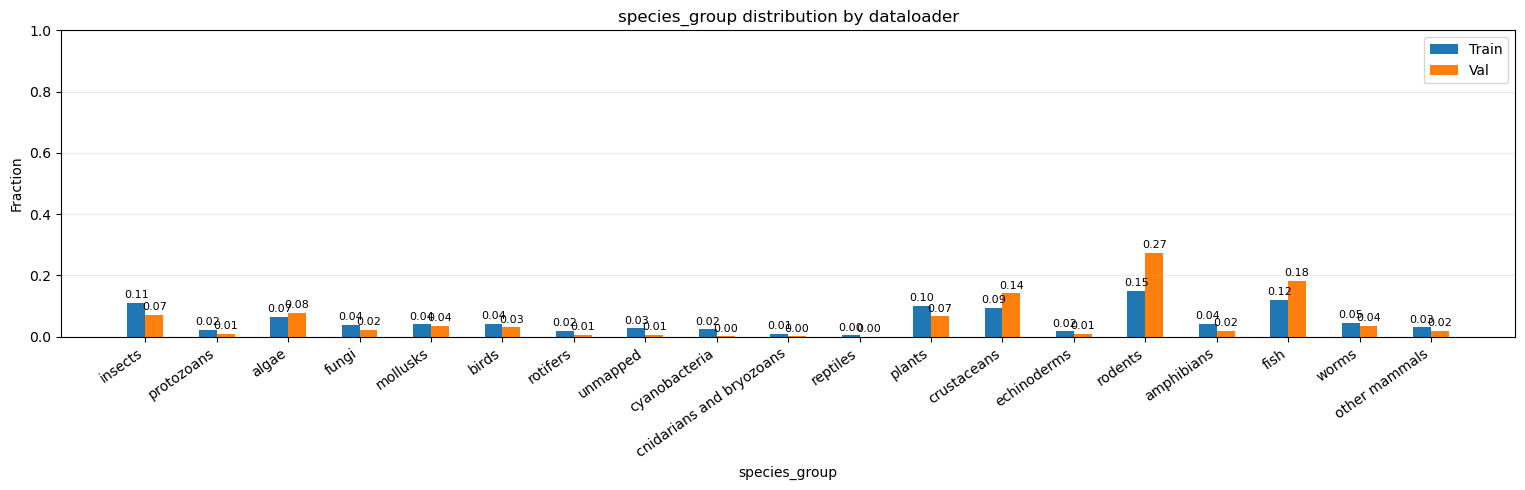

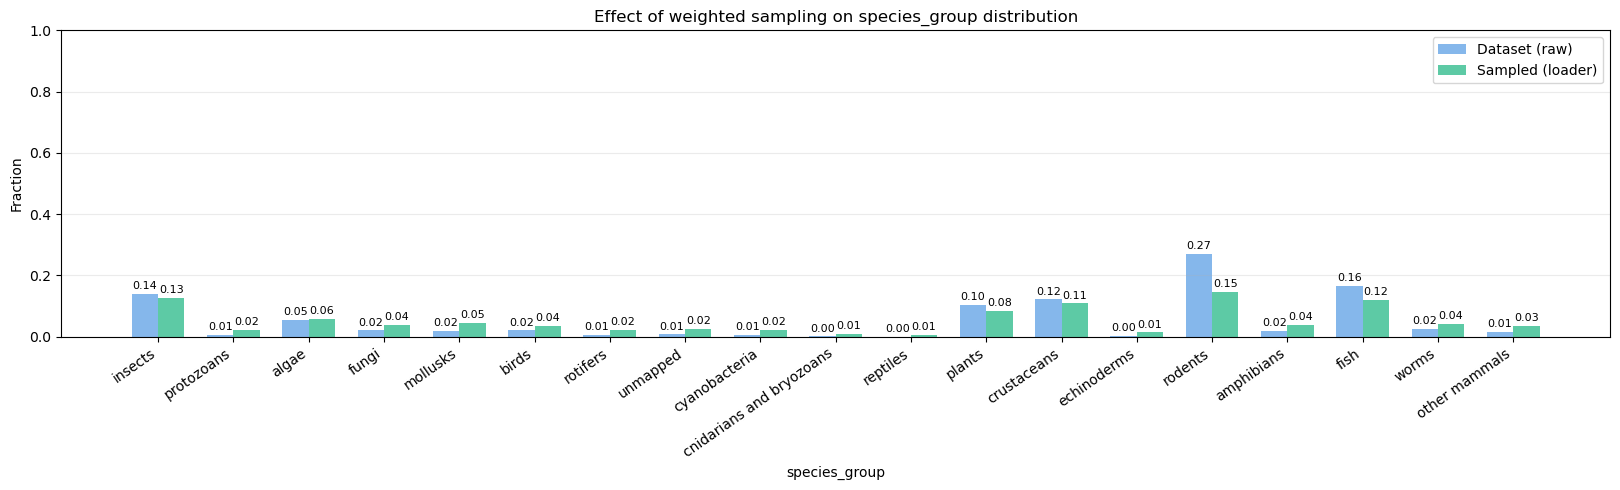

In [9]:
BATCH_SIZE = 256
attribute = "species_group"

train_loader = LoadData(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler_type="weighted",
    shuffle=False, 
    attribute=attribute
)

val_loader = LoadData(
    dataset=val_dataset, 
    batch_size=BATCH_SIZE, 
    sampler_type="sequential",
    shuffle=False, 
    attribute=attribute,
    target_dataset=train_dataset
)

test_loader = None
if test_dataset is not None:
    test_loader = LoadData(
        dataset=test_dataset, 
        batch_size=BATCH_SIZE, 
        sampler_type="sequential",
        shuffle=False, 
        attribute=attribute,
        target_dataset=train_dataset
    )

show_loader_info(attribute, train_loader, val_loader, test_loader, species_group_decoder)

display_sampling_effect(train_dataset, train_loader, "species_group", species_group_decoder)

# Model and training


## Build model

In [11]:
from src.models.gin import GIN
from src.models.gat import GATv2
from src.models.pna import PNA, PNA_1_5M_CONFIG, compute_pna_degree_histogram
from src.models.afp_flex import AFPFlex
from src.models.combo import Combo
from src.models.fragVirtualComboPNAInit import FragVirtualComboPNAInit
from src.models.toxicity_model import ToxicityModel
from src.models.meta_encoder import MetaEncoder, TaxonomyEncoder, TaxonomyOneHot

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

########## MODEL HYPERPARAMETERS ##########

PRETRAINED_TAX_DIM = 768 # 768 is the length of the vectors in pretrained_tax_emb.pkl.zip
PRETRAINED_TAXID_OUTPUT_DIM = 64
CATEGORICAL_DIM = 16
NUMERIC_DIM = 16
META_DROPOUT = 0.3

GNN_HIDDEN_DIM = 64
TOWERS = 4
GNN_OUT_DIM = 64

NUM_LAYERS = 2
NUM_TIMESTEPS = 1
DROPOUT = 0.3

FINAL_HIDDEN_DIM = 64

ATOM_FEATURE_DIM = graphs[0].x.shape[1]
EDGE_FEATURE_DIM = graphs[0].edge_attr.shape[1]
VIRTUAL_EDGE_FEATURE_DIM = graphs[0].virtual_edge_attr.shape[1] if hasattr(graphs[0], "virtual_edge_attr") else 0

def build_model():
    meta_encoder = MetaEncoder(
        pretrained_taxid_path=PRETRAINED_TAXID_PATH if USE_PRETRAINED_TAXID else None,
        pretrained_tax_dim=PRETRAINED_TAX_DIM,
        pretrained_taxid_output_dim=PRETRAINED_TAXID_OUTPUT_DIM,
        config_categorical=config_categorical,
        categorical_output_dim=CATEGORICAL_DIM,
        numerical_columns=NUMERICAL_COLS,
        numeric_output_dim=NUMERIC_DIM,
        dropout=META_DROPOUT
    ).to(device)

    # meta_encoder = None

    pna_deg = compute_pna_degree_histogram(train_dataset)

    model_gnn = FragVirtualComboPNAInit(
        in_channels=ATOM_FEATURE_DIM,
        edge_dim=EDGE_FEATURE_DIM,
        virtual_edge_dim=VIRTUAL_EDGE_FEATURE_DIM,
        hidden_dim=GNN_HIDDEN_DIM,
        towers=TOWERS,
        deg=pna_deg,
        out_dim=GNN_OUT_DIM,
        num_layers=NUM_LAYERS,
        num_timesteps=NUM_TIMESTEPS,
        dropout=DROPOUT,
    ).to(device)

    # model_gnn = None

    model = ToxicityModel(
        model_gnn,
        meta_encoder,
        hidden_dim=FINAL_HIDDEN_DIM,
    ).to(device)

    n_params_meta = sum(p.numel() for p in meta_encoder.parameters() if p.requires_grad) if meta_encoder else 0
    n_params_gnn = sum(p.numel() for p in model_gnn.parameters() if p.requires_grad) if model_gnn else 0
    n_params_total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    gnn_name = type(model_gnn).__name__ if model_gnn is not None else "metadata_only"

    return model, meta_encoder, model_gnn, n_params_meta, n_params_gnn, n_params_total, gnn_name

model, meta_encoder, model_gnn, n_params_meta, n_params_gnn, n_params_total, gnn_name = build_model()


print(f"Device: {device}")
print(f"Meta encoder trainable parameters: {n_params_meta:,}")
print(f"GNN trainable parameters: {n_params_gnn:,}")
print(f"Total trainable parameters: {n_params_total:,}")
print()
print(model)


Device: cpu
Meta encoder trainable parameters: 642,256
GNN trainable parameters: 301,504
Total trainable parameters: 958,289

ToxicityModel(
  (gnn): FragVirtualComboPNAInit(
    (lin1): Linear(in_features=187, out_features=64, bias=True)
    (gat): GATv2Conv(64, 64, heads=1)
    (pna): PNAConv(64, 64, towers=4, edge_dim=14)
    (virtual_gat): GATv2Conv(64, 64, heads=1)
    (virtual_gate): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): Sigmoid()
    )
    (gru): GRUCell(128, 64)
    (atom_gats): ModuleList(
      (0): GATv2Conv(64, 64, heads=1)
    )
    (atom_grus): ModuleList(
      (0): GRUCell(64, 64)
    )
    (mol_gat): GATv2Conv(64, 64, heads=1)
    (mol_gru): GRUCell(64, 64)
    (frag_gat): GATv2Conv(64, 64, heads=1)
    (frag_gru): GRUCell(64, 64)
    (frag_lin): Linear(in_features=64, out_features=64, bias=True)
    (lin2): Linear(in_features=128, out_features=64, bias=True)
    (lin3): Linear(in_features=64, out_features=64, bias=True)


## Train The Model


In [12]:
epochs = 100
learning_rate = 3e-4
weight_decay = 1e-4
loss_beta = 0.5
early_stopping_patience = 30
early_stopping_min_delta = 1e-4
record_categories = ["species_group", "endpoint", "effect", "conc_unit"]
BATCH_SIZE = globals().get("BATCH_SIZE", 256)
attribute = globals().get("attribute", "species_group")

wandb_run = None
fold_id = 0
print(f"at fold {fold_id}")

train_idx, val_idx = splits[fold_id]

train_dataset = _build_dataset(graphs, train_idx)
val_dataset = _build_dataset(graphs, val_idx)
test_dataset = None

loss_fn = torch.nn.SmoothL1Loss(beta=loss_beta)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=10,
    factor=0.5,
    min_lr=1e-6,
)

if USE_WANDB:
    wandb_run = wandb.init(
        project="gnn-thesis",
        entity="elonvg-chalmers-university-of-technology",
        job_type="train",
        group=f"{gnn_name}-groupkfold-{random_state}",   # same for all folds
        name=f"{gnn_name}-fold-testt-{fold_id}",               # unique per fold
        tags=["notebook", gnn_name],
        config={
            "random_state": random_state,
            "n_samples": N_SAMPLES,
            "fold": fold_id,
            "folds": folds,
            "train_size": len(train_dataset),
            "val_size": len(val_dataset),

            "filters": FILTERS,
            "split_salt": SPLIT_SALTS,
            "remove_lone": REMOVE_LONE,
            "remove_metals": REMOVE_METALS,
            "max_conc_value": MAX_CONC_VALUE,
            "duration_fill_value": DURATION_FILL_VALUE,
            "max_duration_hours": MAX_DURATION_HOURS,
            
            "num_atom_features": ATOM_FEATURE_DIM,
            "num_bond_features": EDGE_FEATURE_DIM,

            "use_pretrained_taxid": USE_PRETRAINED_TAXID,
            "categorical_cols": CATEGORICAL_COLS,
            "numerical_cols": NUMERICAL_COLS,

            # "split_method": split_method,
            "butina_cluster_col": cluster_col,
            # "stratify_by": stratify_by,
            # "frac_train": frac_train,
            # "frac_valid": frac_valid,
            # "frac_test": frac_test,
            # "target_mean": float(target_mean),
            # "target_std": float(target_std),

            "batch_size": BATCH_SIZE,
            "taxonomy_encoder": TaxonomyOneHot.__name__,
            "gnn_model": f"{gnn_name}-testt-",
            "pretrained_tax_dim": PRETRAINED_TAX_DIM,
            "pretrained_taxid_output_dim": PRETRAINED_TAXID_OUTPUT_DIM,
            "categorical_dim": CATEGORICAL_DIM,
            "numeric_dim": NUMERIC_DIM,
            "meta_dropout": META_DROPOUT,
            "gnn_hidden_dim": GNN_HIDDEN_DIM,
            "gnn_towers": TOWERS,
            "gnn_out_dim": GNN_OUT_DIM,
            "num_layers": NUM_LAYERS,
            "num_timesteps": NUM_TIMESTEPS,
            "dropout": DROPOUT,
            "final_hidden_dim": FINAL_HIDDEN_DIM,
            "n_params_meta": n_params_meta,
            "n_params_gnn": n_params_gnn,
            "n_params_total": n_params_total,
            "learning_rate": learning_rate,
            "weight_decay": weight_decay,
            "loss": loss_fn.__class__.__name__,
            "loss_beta": loss_beta,
            "early_stopping_patience": early_stopping_patience,
            "early_stopping_min_delta": early_stopping_min_delta,
        },
    )
    wandb_run.define_metric("epoch")
    metric_prefixes = ["train/*", "val/*", "optimizer/*"]
    if test_loader is not None:
        metric_prefixes.append("test/*")
    for metric_prefix in metric_prefixes:
        wandb_run.define_metric(metric_prefix, step_metric="epoch")
else:
    print("wandb not installed; running without experiment tracking.")

print("Training configuration")
print(f"epochs = {epochs}")
print(f"learning_rate = {learning_rate}")
print(f"weight_decay = {weight_decay}")
print(f"loss = {loss_fn.__class__.__name__}")
print(f"early_stopping_patience = {early_stopping_patience}")

model_trained, history = train(
    model,
    train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    epochs=epochs,
    device=device,
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    record_categories=CATEGORICAL_COLS,
    record_joint_categories=("endpoint", "species_group"),
    label_encoder=categorical_encoder,
    run=wandb_run,
)

model = model_trained

if wandb_run is not None:
    wandb_run.finish()
    wandb_run = None

# plot_training(history["history_all"])

# plot_training_metrics(history["history_all"])


at fold 0


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/vollmers/.netrc.
wandb: Currently logged in as: elonvg (elonvg-chalmers-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training configuration
epochs = 100
learning_rate = 0.0003
weight_decay = 0.0001
loss = SmoothL1Loss
early_stopping_patience = 30


Epoch 88/100:  87%|████████▋ | 87/100 [03:55<00:35,  2.70s/epoch, train_loss=0.6024, val_loss=0.8629, val_rmse=1.4337, val_mean_ae=1.0880, val_median_ae=0.8436, lr=3.75e-05]


Early stopping at epoch 88: no improvement in val_loss for 30 epochs.


cat_conc_unit/%/val_mean_ae,▁▅▃▄▆▇▅▅▄▄▄▄▅▆▄▆▄▆█▆▆▆▅▆▇▆▆▅▅▆▆▆▆▆▇▇▇▇█▇
cat_conc_unit/%/val_median_ae,▃▄▄▂▅▄▅▆▄▄▅▆▃▆▃▅▃▆█▇▆█▁▆▆█▆█▇▆█▄▅▆▅▆▅▆▅▅
cat_conc_unit/%/val_rmse,▁▄▃▃▄▆▄▅▅▄▄▄▄▄▆▆▅▆▇▅▆▆▇▇▇▇█▆▇▆▆▇▇▇██▇███
cat_conc_unit/kg/m2/val_mean_ae,█▃▄▃▃▃▂▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cat_conc_unit/kg/m2/val_median_ae,█▅▅▃▄▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▂▁▁▁▂▁▁▁▁
cat_conc_unit/kg/m2/val_rmse,█▆▄▃▄▃▂▂▂▂▁▁▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cat_conc_unit/mL/kg bw/val_mean_ae,▁▆▅▅▅▆▆▆▅█▆▇▅▄▆▄▅▅▃▄▅▄▄▃▄▃▄▄▄▃▃▃▃▃▃▃▃▃▃▃
cat_conc_unit/mL/kg bw/val_median_ae,▁▄▅▃▆▄█▆▄▁▂▇▄▃▇▄▅▂▆▂▅▅▄▅▃▂▄▃▃▂▂▂▂▁▂▃▂▁▂▂
cat_conc_unit/mL/kg bw/val_rmse,▁▆▇▆▅▇▆▆█▇▅▆▄▅▄▅▃▄▃▄▃▅▅▃▃▄▅▃▄▃▄▅▃▂▃▄▃▄▃▃
cat_conc_unit/mg/L/val_mean_ae,█▆▇█▇▇█▅▅▅▄▄▄▃▄▃▃▃▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▂▁▂
+199,...
